In [77]:
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
import os
load_dotenv()


if os.environ['GEMINI_API_KEY']:
    print('gemini key set')
else:
    print("not set")


gemini key set


# **Initialize LLM**

In [78]:
# Initialize the Gemini model
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0.7,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)

llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain-google-genai': '4.3.4'}}, profile={'name': 'Gemini 3.1 Flash Lite', 'release_date': '2026-05-07', 'last_updated': '2026-05-07', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'minimal'}, google_api_key=SecretStr('**********'), model='gemini-3.1-flash-lite', max_retries=2, client=<google.genai.client.Client object at 0x000001A3FB3B4050>, default_metadata=(), model_kwargs={})

In [79]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

llm.invoke(
    [HumanMessage(content="What is the capital of France?")]
)

AIMessage(content=[{'type': 'text', 'text': 'The capital of France is Paris.', 'extras': {'signature': 'EnEKbwERTTIPhHH2whmO1/yISnl8/RB/evjeyEQss5QuJxEmFw6vguGwXrgIM+DjDU3Uuq1YWZF8hH9E8E+eEuj8mpOJ2cTYdyT3fdxOg1sN8LghfQzWAApHP3XKn+T3hyQSs5+BevCVxVctFv4e/bhzqQ=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a01fbd-69ca-7ed1-958a-b2adf02d40cd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 7, 'total_tokens': 15, 'input_token_details': {'cache_read': 0}})

In [80]:
from typing import TypedDict, List, Annotated
from operator import add

class GraphSchema(TypedDict):
    messages_manual: List
    # using reducer
    messages_auto: Annotated[List, add]
    

In [81]:
def create_post(state:GraphSchema) -> GraphSchema:
    
    # convert the state object to a dictionary
    # state = state.model_dump()
    
    messages_manual = state['messages_manual']
    # messages_auto = state['messages_auto']
    
    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content = response_manual)
    
    state['messages_manual'] = messages_manual + [response_manual_ai]
    
    messages_auto = state['messages_auto']
    response_auto = llm.invoke(messages_auto).content
    response_auto_ai = AIMessage(content = response_auto)
    state['messages_auto'] = [response_auto_ai]
    
    return state


def curate_post(state:GraphSchema) -> GraphSchema:
    
    # convert the state object to a dictionary
    # state = state.model_dump()
    
    messages_manual = state['messages_manual']
    
    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content = response_manual)
    state['messages_manual'] = messages_manual + [response_manual_ai]
    
    
    messages_auto = state['messages_auto']
    response_auto = llm.invoke(messages_auto).content
    response_auto_ai = AIMessage(content = response_auto)
    state['messages_auto'] = [response_auto_ai]
    
    return state


In [82]:
import os

os.environ.pop("CURL_CA_BUNDLE", None)

print("CURL_CA_BUNDLE =", os.environ.get("CURL_CA_BUNDLE"))

CURL_CA_BUNDLE = None


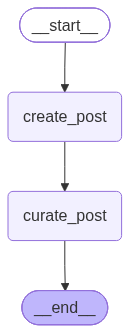

In [83]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

graph = StateGraph(GraphSchema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)



messages_graph = graph.compile()

Image(messages_graph.get_graph().draw_mermaid_png())

In [84]:
messages_graph.invoke(
    {
        "messages_manual": [HumanMessage(content="The future of AI in healthcare")],
        "messages_auto":[HumanMessage(content="importance of water")]
    }
)

{'messages_manual': [HumanMessage(content='The future of AI in healthcare', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'type': 'text', 'text': 'The integration of Artificial Intelligence (AI) into healthcare is not just a technological upgrade; it is a fundamental shift in how medicine is practiced. We are moving from a "one-size-fits-all" reactive model to a proactive, predictive, and personalized system.\n\nHere is a look at the trajectory of AI in healthcare across five key domains:\n\n### 1. Precision Medicine and Genomics\nCurrently, most treatments are based on population averages. AI is changing this by analyzing a patient’s unique genetic makeup, lifestyle, and environment to tailor treatments.\n*   **Predictive Analytics:** AI models can now predict which patients are at high risk for specific conditions (like heart disease or diabetes) years before symptoms appear, allowing for early intervention.\n*   **Drug Discovery:** Developing a new drug traditio